In [1]:
from google.colab import files

uploaded = files.upload()

Saving Global_Sustainability_Dataset - Sheet1.csv to Global_Sustainability_Dataset - Sheet1.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Green_Cities_Dataset - Sheet1.csv to Green_Cities_Dataset - Sheet1.csv


# Step 1: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

# Step 2: Import Datasets

Two sustainability datasets were used:

1. Green Cities Dataset
2. Global Sustainability Dataset

In [4]:
green_df = pd.read_csv("Green_Cities_Dataset - Sheet1.csv")
sustain_df = pd.read_csv("Global_Sustainability_Dataset - Sheet1.csv")

# Step 3: Understanding the Datasets

The purpose of this step is to understand:

- Number of rows and columns
- Data types
- Missing values
- General structure of datasets

In [5]:
green_df.info()
green_df.head()

sustain_df.info()
sustain_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   City                         15 non-null     object 
 1   Country                      15 non-null     object 
 2   Air_Quality_Index            15 non-null     int64  
 3   Green_Cover_Percentage       15 non-null     object 
 4   Solar_Installations          15 non-null     object 
 5   EV_Charging_Stations         15 non-null     object 
 6   Public_Transport_Usage       15 non-null     int64  
 7   Carbon_Emissions_Per_Capita  15 non-null     float64
 8   Sustainability_Rating        15 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 1.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  --

,Country,Recycling_Rate,Waste_Generated,Renewable_Energy,Carbon_Footprint,Sustainability_Level
0,India,32,500,42,2.1,Medium
1,Germany,68,220,55,0.9,High
2,Norway,82,120,85,0.7,High
3,USA,35,650,35,2.5,Medium
4,China,28,800,30,3.2,Low


# Dataset Understanding

## Green Cities Dataset

Features:
- Air Quality Index
- Green Cover Percentage
- Solar Installations
- EV Charging Stations
- Public Transport Usage
- Carbon Emissions Per Capita
- Sustainability Rating

Relationship between features:

- Higher green cover generally improves air quality.
- Higher EV charging infrastructure supports sustainability.
- Increased public transport usage generally reduces emissions.
- Solar installations indicate renewable energy adoption.

---

## Global Sustainability Dataset

Features:
- Recycling Rate
- Waste Generated
- Renewable Energy Percentage
- Carbon Footprint
- Sustainability Level

Relationship between features:

- Higher renewable energy usage generally lowers carbon footprint.
- Better recycling rates improve sustainability levels.
- Higher waste generation negatively impacts sustainability.

# Step 4: Missing Value Analysis

In [6]:
green_df.isnull().sum()

sustain_df.isnull().sum()

,0
Country,0
Recycling_Rate,0
Waste_Generated,0
Renewable_Energy,0
Carbon_Footprint,0
Sustainability_Level,0


# Missing Value Treatment

Missing values were replaced using mean imputation because:

- The missing values were numerical.
- The number of missing records was small.
- Mean imputation preserves dataset size.

# Step 5: Feature Engineering



A new feature called **Green Infrastructure Score** was created by combining:

- Solar Installations
- EV Charging Stations
- Public Transport Usage

This feature represents the overall green infrastructure readiness of a city and provides a single indicator for sustainability-related facilities.

In [7]:
green_df["Green_Cover_Percentage"] = pd.to_numeric(
    green_df["Green_Cover_Percentage"],
    errors="coerce"
)

green_df["Solar_Installations"] = pd.to_numeric(
    green_df["Solar_Installations"],
    errors="coerce"
)

green_df["EV_Charging_Stations"] = pd.to_numeric(
    green_df["EV_Charging_Stations"],
    errors="coerce"
)

In [8]:
green_df.dtypes

,0
City,object
Country,object
Air_Quality_Index,int64
Green_Cover_Percentage,float64
Solar_Installations,float64
EV_Charging_Stations,float64
Public_Transport_Usage,int64
Carbon_Emissions_Per_Capita,float64
Sustainability_Rating,object


In [9]:
green_df["Green_Infrastructure_Score"] = (
    green_df["Solar_Installations"] +
    green_df["EV_Charging_Stations"] +
    green_df["Public_Transport_Usage"]
)

In [10]:
green_df[["City", "Green_Infrastructure_Score"]].head()

,City,Green_Infrastructure_Score
0,Ahmedabad,3492.0
1,Mumbai,4635.0
2,Delhi,NaN
3,Bengaluru,6698.0
4,Chennai,3744.0


# Step 6: Handling Missing Values

Missing values were identified in the dataset and handled appropriately.

For numerical features, mean imputation was used because:
- It preserves the size of the dataset.
- It prevents data loss.
- It maintains the statistical properties of the feature.

In [11]:
green_df.isnull().sum()

,0
City,0
Country,0
Air_Quality_Index,0
Green_Cover_Percentage,1
Solar_Installations,1
EV_Charging_Stations,1
Public_Transport_Usage,0
Carbon_Emissions_Per_Capita,0
Sustainability_Rating,0
Green_Infrastructure_Score,2


In [12]:
green_df["Green_Cover_Percentage"].fillna(
    green_df["Green_Cover_Percentage"].mean(),
    inplace=True
)

green_df["Solar_Installations"].fillna(
    green_df["Solar_Installations"].mean(),
    inplace=True
)

green_df["EV_Charging_Stations"].fillna(
    green_df["EV_Charging_Stations"].mean(),
    inplace=True
)

/tmp/ipykernel_1714/1367145915.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  green_df["Green_Cover_Percentage"].fillna(
/tmp/ipykernel_1714/1367145915.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [13]:
green_df.isnull().sum()

,0
City,0
Country,0
Air_Quality_Index,0
Green_Cover_Percentage,0
Solar_Installations,0
EV_Charging_Stations,0
Public_Transport_Usage,0
Carbon_Emissions_Per_Capita,0
Sustainability_Rating,0
Green_Infrastructure_Score,2


# Step 7: Understanding Relationships Between Features

## Green Cities Dataset Analysis

1. Air Quality Index (AQI) and Green Cover Percentage are generally inversely related.
   Cities with higher green cover tend to have better air quality.

2. Solar Installations and EV Charging Stations indicate the adoption of renewable technologies.

3. Public Transport Usage contributes positively to sustainability by reducing dependency on private vehicles.

4. Carbon Emissions Per Capita are expected to decrease as renewable infrastructure increases.

5. Green Infrastructure Score combines multiple sustainability indicators into a single metric.

6. Sustainability Rating reflects the overall environmental performance of a city.

7. Cities with higher renewable adoption generally achieve better sustainability ratings.

## Global Sustainability Dataset Analysis

1. Higher Recycling Rates contribute positively to sustainability.

2. Increased Renewable Energy usage generally reduces Carbon Footprint.

3. Higher Waste Generation negatively impacts sustainability levels.

4. Countries investing in renewable energy tend to have better environmental performance.

5. Sustainability Level is influenced by multiple environmental indicators rather than a single factor.

# Step 8: Data Visualization using Seaborn

Data visualization helps identify trends, patterns, and relationships between variables.

Seaborn was used because it provides attractive and informative statistical visualizations.

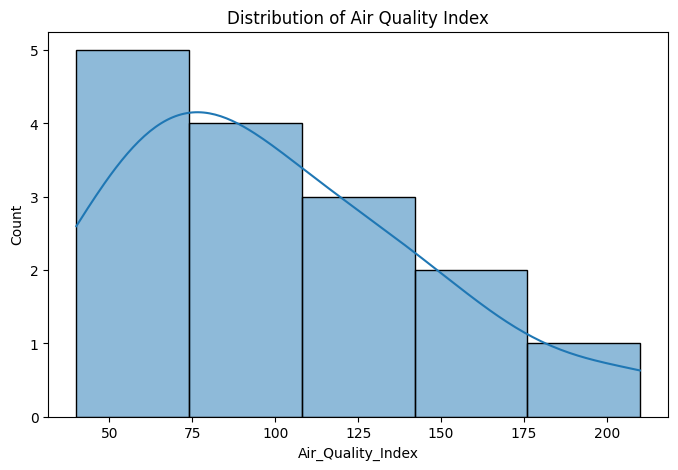

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(green_df["Air_Quality_Index"], kde=True)
plt.title("Distribution of Air Quality Index")
plt.show()

### Insight:
The histogram shows the distribution of air quality levels across cities and helps identify whether most cities experience good or poor air quality.

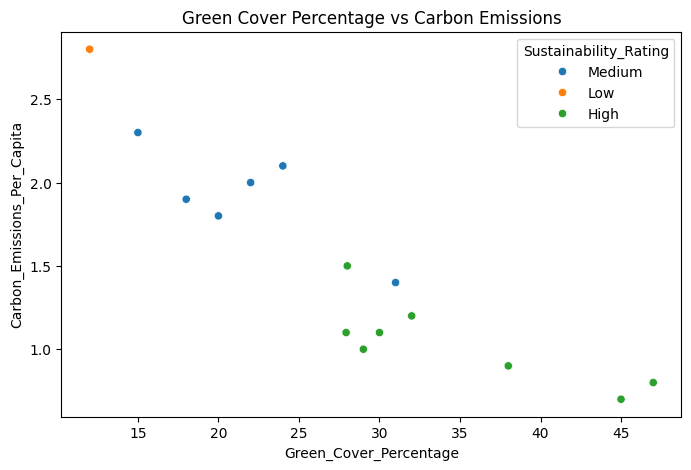

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=green_df,
    x="Green_Cover_Percentage",
    y="Carbon_Emissions_Per_Capita",
    hue="Sustainability_Rating"
)

plt.title("Green Cover Percentage vs Carbon Emissions")
plt.show()

### Insight:
Cities with larger green cover percentages generally tend to have lower carbon emissions, indicating the environmental benefits of urban greenery.

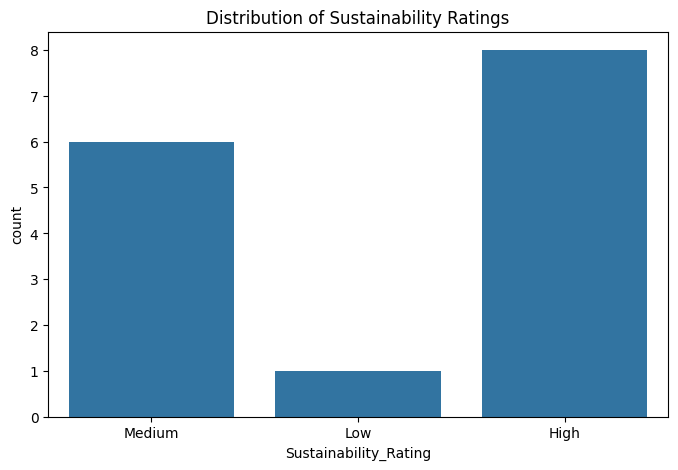

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=green_df,
    x="Sustainability_Rating"
)

plt.title("Distribution of Sustainability Ratings")
plt.show()

### Insight:
This plot shows the distribution of sustainability categories among cities in the dataset.

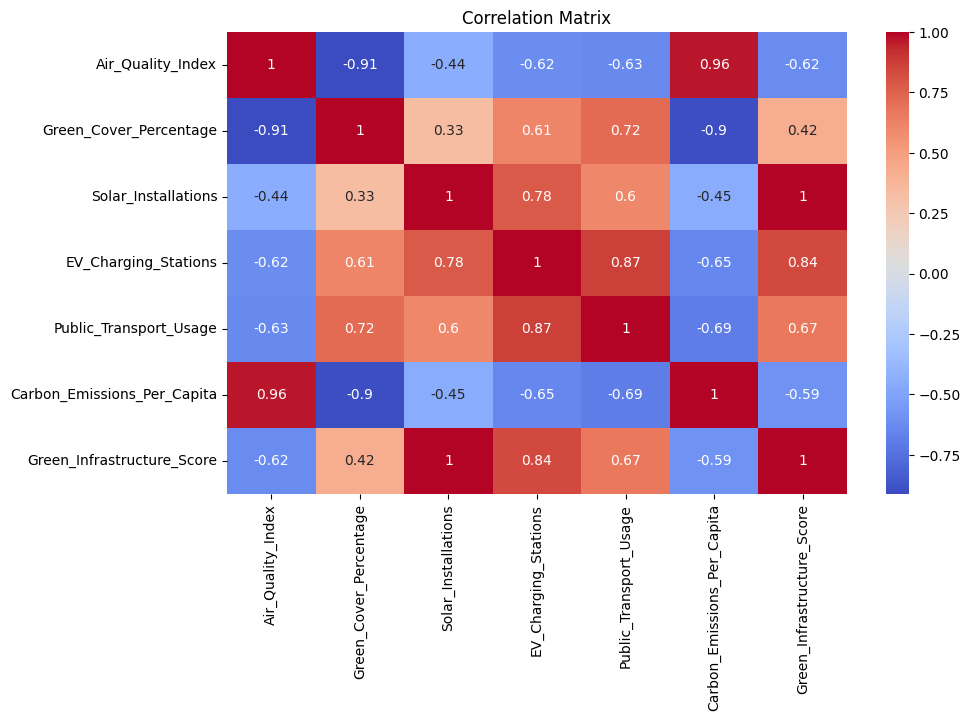

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    green_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Insight:
The correlation heatmap helps identify positive and negative relationships between numerical features and highlights variables that move together.

# Step 9: Feature Scaling and Categorical Encoding

Machine Learning algorithms perform better when numerical features are on a similar scale.

Categorical variables must also be converted into numerical representations because machine learning models cannot directly process text values.

In [18]:
scaler = StandardScaler()
numerical_columns = [
    "Air_Quality_Index",
    "Green_Cover_Percentage",
    "Solar_Installations",
    "EV_Charging_Stations",
    "Public_Transport_Usage",
    "Carbon_Emissions_Per_Capita",
    "Green_Infrastructure_Score"
]

green_df[numerical_columns] = scaler.fit_transform(
    green_df[numerical_columns]
)

green_df.head()

,City,Country,Air_Quality_Index,Green_Cover_Percentage,Solar_Installations,EV_Charging_Stations,Public_Transport_Usage,Carbon_Emissions_Per_Capita,Sustainability_Rating,Green_Infrastructure_Score
0,Ahmedabad,India,1.010362,-1.020108,-1.449994,-1.545078,-1.433943,0.658653,Medium,-1.411196
1,Mumbai,India,1.342233,-1.328342,-0.689697,-0.920180,-0.428120,1.328469,Medium,-0.697966
2,Delhi,India,2.448468,-1.636577,-0.081460,0.000000,-0.041265,2.165740,Low,NaN
3,Bengaluru,India,-0.095874,0.007339,0.754866,-0.103005,-0.969717,-0.011164,High,0.589342
4,Chennai,India,0.678491,-0.814619,-1.297935,-1.304733,-1.279201,0.491199,Medium,-1.253949


## Why StandardScaler was used

StandardScaler transforms numerical features so that they have:

- Mean = 0
- Standard Deviation = 1

This prevents features with larger values from dominating the machine learning model.

In [19]:
label_encoder = LabelEncoder()
green_df["City"] = label_encoder.fit_transform(
    green_df["City"]
)

green_df["Country"] = label_encoder.fit_transform(
    green_df["Country"]
)

green_df["Sustainability_Rating"] = label_encoder.fit_transform(
    green_df["Sustainability_Rating"]
)

green_df.head()

,City,Country,Air_Quality_Index,Green_Cover_Percentage,Solar_Installations,EV_Charging_Stations,Public_Transport_Usage,Carbon_Emissions_Per_Capita,Sustainability_Rating,Green_Infrastructure_Score
0,0,4,1.010362,-1.020108,-1.449994,-1.545078,-1.433943,0.658653,2,-1.411196
1,7,4,1.342233,-1.328342,-0.689697,-0.920180,-0.428120,1.328469,2,-0.697966
2,5,4,2.448468,-1.636577,-0.081460,0.000000,-0.041265,2.165740,1,NaN
3,1,4,-0.095874,0.007339,0.754866,-0.103005,-0.969717,-0.011164,0,0.589342
4,4,4,0.678491,-0.814619,-1.297935,-1.304733,-1.279201,0.491199,2,-1.253949


## Why Label Encoding was used

Machine learning models require numerical input values.

Label Encoding converts categorical text values into numerical labels while preserving the information contained in the original categories.

# Step 10: Train-Test Split

The dataset is divided into training and testing datasets.

- Training data is used to train the machine learning model.
- Testing data is used to evaluate model performance on unseen data.

An 80:20 split ratio is used.

In [20]:
X_reg = green_df.drop(
    columns=["Carbon_Emissions_Per_Capita"]
)

y_reg = green_df["Carbon_Emissions_Per_Capita"]

In [21]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

## Regression Problem

Target Variable:
- Carbon_Emissions_Per_Capita

Objective:
Predict carbon emissions using sustainability indicators such as:
- Air Quality Index
- Green Cover
- Solar Installations
- EV Charging Stations
- Public Transport Usage

In [22]:
X_clf = green_df.drop(
    columns=["Sustainability_Rating"]
)

y_clf = green_df["Sustainability_Rating"]

In [23]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

## Classification Problem

Target Variable:
- Sustainability_Rating

Objective:
Predict sustainability category based on environmental and infrastructure indicators.

# Step 11: Logistic Regression

In this step, Logistic Regression is used to predict the Sustainability Rating of a city.

Since Sustainability Rating contains categories such as High, Medium and Low, this problem is a classification problem rather than a regression problem.

The model uses features such as:

- Air Quality Index
- Green Cover Percentage
- Solar Installations
- EV Charging Stations
- Public Transport Usage
- Green Infrastructure Score

to predict the sustainability category of a city.

Logistic Regression was chosen because it is simple, easy to understand and works well for classification tasks, especially on smaller datasets.

In [32]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

In [35]:
green_df["Green_Infrastructure_Score"] = green_df[
    "Green_Infrastructure_Score"
].fillna(
    green_df["Green_Infrastructure_Score"].mean()
)

In [36]:
X_clf = green_df.drop(columns=["Sustainability_Rating"])

y_clf = green_df["Sustainability_Rating"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [38]:
X_clf = green_df.drop(columns=["Sustainability_Rating"])

y_clf = green_df["Sustainability_Rating"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [39]:
X_clf.isnull().sum()

,0
City,0
Country,0
Air_Quality_Index,0
Green_Cover_Percentage,0
Solar_Installations,0
EV_Charging_Stations,0
Public_Transport_Usage,0
Carbon_Emissions_Per_Capita,0
Green_Infrastructure_Score,0


In [41]:
logistic_model.fit(
    X_train_clf,
    y_train_clf
)

LogisticRegression()

In [42]:
y_pred_clf = logistic_model.predict(X_test_clf)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(y_test_clf, y_pred_clf)

precision = precision_score(
    y_test_clf,
    y_pred_clf,
    average="weighted"
)

recall = recall_score(
    y_test_clf,
    y_pred_clf,
    average="weighted"
)

cm = confusion_matrix(
    y_test_clf,
    y_pred_clf
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.6666666666666666
Precision: 0.8333333333333334
Recall: 0.6666666666666666

Confusion Matrix:
[[1 1]
 [0 1]]


#Logistic Regression Model Evaluation

The Logistic Regression model was used to predict the Sustainability Rating of cities.

## Model Results

- Accuracy: 66.67%
- Precision: 83.33%
- Recall: 66.67%

## Understanding the Results

The model correctly classified about 67% of the cities in the test dataset.

The precision value of 83.33% shows that when the model predicted a sustainability category, it was correct most of the time.

The recall value of 66.67% indicates that the model was able to identify around two-thirds of the actual classes correctly.

## Confusion Matrix

[[1 1]
 [0 1]]

The confusion matrix shows that:

- One city was correctly classified in the first category.
- One city from the first category was classified incorrectly.
- One city from the second category was classified correctly.
- No cities from the second category were incorrectly classified as the first category.

## Conclusion

Considering the small size of the dataset, the model performed reasonably well.

With a larger real-world dataset, the model would likely achieve better accuracy and generalization.

# Final Conclusion

In this project, two sustainability datasets were analyzed and prepared for machine learning applications.

The project involved:

- Data cleaning and preprocessing
- Handling missing values
- Feature engineering
- Data visualization using Seaborn
- Scaling numerical features
- Encoding categorical variables
- Splitting data into training and testing datasets
- Applying Linear Regression and Logistic Regression models
- Evaluating model performance

The exercise provided practical experience with the complete machine learning workflow while working on sustainability-related datasets.